# Module 2 · Transformers — Lab 3: Fine-tuning knobs
## Where the classifier reads, how deep it trains, and where its accuracy comes from

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/mago-cinv/course-template/blob/master/modules/02-transformers/labs/homework/lab-3-variants-assignament.ipynb)

This homework pairs with **Lesson 3** ("Architecture variations"), and uses two of its families —
`distilbert-base-uncased` (encoder-only) and `gpt2` (decoder-only) — on one application: **binary
sentiment classification on SST-2**.

### The question behind the whole lab

Fine-tuning a pretrained transformer for classification looks like three lines of Hugging Face. Those
three lines quietly decide several things for you. `AutoModelForSequenceClassification` **hardcodes
which hidden state the classifier head reads** — BERT's pooler takes `[CLS]`, GPT-2 takes the last
non-pad token — and the usual recipe fine-tunes *every* weight in the body without ever asking how
many of them actually needed to move.

Nobody asked whether those are the right choices. To ask, each one has to become a **knob** you can
turn and measure, which means writing our own classifier head. That is what the knob bench in Part 0
is for.

### How this homework works

**The machinery is given to you and has already run.** Part 0 loads a small SST-2 slice and builds
the bench: a classifier whose readout position is configurable, a fine-tune function that **hands the
trained model back to you**, and a grid runner that sweeps configurations into a table and a plot.
None of it needs you to look up a library signature — it is all written, commented, and demonstrated
below.

**What you write is the investigation.** Four experiments (🔬 **A1**–**A4**) point that bench at four
questions: *where* should the head read from, *how much* of the body has to move, *where* the accuracy
actually comes from, and *what* the trained model really does on sentences you wrote yourself. The
experiments must *run*, because every conclusion has to cite numbers **you** printed.

**Before submitting:** *Kernel → Restart & Run All*, then leave all outputs visible so your write-ups
can be checked against the evidence they cite.

*Knob set adapted from the ablation table in [`rasbt/LLMs-from-scratch`](https://github.com/rasbt/LLMs-from-scratch/tree/main/ch06/02_bonus_additional-experiments)
(`ch06/02_bonus_additional-experiments`, Apache-2.0) — the questions are borrowed, the code here is
written fresh against this notebook's own sandbox.*

*Model downloads ≈ 0.5 GB (two checkpoints), cached after the first run. On Colab use **Runtime ▸
Change runtime type ▸ GPU** if you have it. Fine-tuned weights are **hardware-dependent** — same seed
on a different machine gives visibly different numbers; that is expected, and nothing here is graded
against a reference figure.*

In [2]:
# Setup — run me first (works on Colab AND locally)
import sys

if "google.colab" in sys.modules:
    %pip install -q transformers datasets evaluate accelerate

print("Setup OK —", "Colab" if "google.colab" in sys.modules else "local Python", sys.version.split()[0])

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 8.0 MB/s eta 0:00:00
Setup OK — Colab 3.13.15


In [3]:
# Imports, seeds, device — run me second
import gc, math, os, re, time, warnings

warnings.filterwarnings("ignore")
os.environ["TOKENIZERS_PARALLELISM"] = "false"

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import transformers
from datasets import load_dataset
from transformers import (AutoConfig, AutoModel, AutoTokenizer,
                           DataCollatorWithPadding, Trainer, TrainingArguments, set_seed)

transformers.logging.set_verbosity_error()   # quiet down "newly initialized weights" chatter

SEED = 0
set_seed(SEED); torch.manual_seed(SEED); np.random.seed(SEED)

DEVICE = ("cuda" if torch.cuda.is_available()
          else "mps" if torch.backends.mps.is_available() else "cpu")
print(f"device: {DEVICE}")
if DEVICE == "cpu":
    print("  ⏳ running on CPU.")
    print("     On Colab, Runtime ▸ Change runtime type ▸ GPU will be faster if available.")
else:
    print("  ✓ accelerator found.")
print("⚠ ~0.5 GB of model downloads on first run (distilbert-base-uncased + gpt2), cached after.")
print("⚠ Fine-tuned weights are HARDWARE-dependent: same seed, different machine → visibly different")
print("   numbers. Nothing here is graded against a reference figure.")

device: cuda
  ✓ accelerator found.
⚠ ~0.5 GB of model downloads on first run (distilbert-base-uncased + gpt2), cached after.
⚠ Fine-tuned weights are HARDWARE-dependent: same seed, different machine → visibly different
   numbers. Nothing here is graded against a reference figure.


## Part 0 — The sandbox (provided, already run)

Everything in Part 0 is **given to you and already works**: the SST-2 slice, two small helpers, and
the knob bench itself (a configurable-readout classifier, a fine-tune-and-keep function, a grid
runner). Read it once, run it, then go use it in A1–A4.

### 0.1 · The task and the data — SST-2

The application is **binary sentiment classification**: given one short movie-review sentence, answer
*positive* or *negative*. **SST-2** (Stanford Sentiment Treebank) is its standard benchmark.

A deterministic slice: the first **300** training sentences to fine-tune on, the first **100** of the
*validation* split as held-out evaluation (SST-2's test labels are hidden). Small on purpose — every
exercise below fine-tunes several models, so each single run has to be cheap.

In [4]:
ds = load_dataset("nyu-mll/glue", "sst2")     # ⚠ gotcha #3: the bare "glue" alias errors on datasets >= 5
train_small = ds["train"].select(range(300))
eval_small = ds["validation"].select(range(100))

names = {0: "negative", 1: "positive"}
print(f"train {len(train_small)}   eval {len(eval_small)}")
print(f"eval class balance: {np.bincount(eval_small['label']).tolist()}  (chance ≈ 0.5)")
print()
for i in (0, 1):
    print(f"  [{names[eval_small[i]['label']]}] {eval_small[i]['sentence'].strip()}")

README.md:   0%|          | 0.00/35.3k [00:00<?, ?B/s]

sst2/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 3.11MB            

sst2/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

sst2/validation-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 72.8kB            

sst2/validation-00000-of-00001.parquet: downloading bytes:           |  0.00B            

...

sst2/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/67349 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/872 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1821 [00:00<?, ? examples/s]

train 300   eval 100
eval class balance: [48, 52]  (chance ≈ 0.5)

  [positive] it 's a charming and often affecting journey .
  [negative] unflinchingly bleak and desperate


### 0.2 · Two small helpers the bench uses

The accuracy metric, the quiet `TrainingArguments` every run shares, and the label words used when a
model's predictions are printed back as text.

In [5]:
LABEL_WORDS = {0: "negative", 1: "positive"}


def _accuracy_metric(eval_pred):
    preds = np.argmax(eval_pred.predictions, axis=-1)
    return {"accuracy": float((preds == eval_pred.label_ids).mean())}


def _quiet_args(out_dir, epochs, batch_size, seed):
    return TrainingArguments(output_dir=out_dir, num_train_epochs=epochs,
                              per_device_train_batch_size=batch_size,
                              per_device_eval_batch_size=batch_size,
                              logging_steps=1000, report_to=[], seed=seed,
                              disable_tqdm=True, eval_strategy="no", save_strategy="no")


print("helpers ready: LABEL_WORDS / _accuracy_metric / _quiet_args")

helpers ready: LABEL_WORDS / _accuracy_metric / _quiet_args


### 0.3 · The knob bench (provided, already run)

One function, `finetune_with_knobs(**knobs)`, fine-tunes a body and **hands the model back**. Every
knob has a default, so `finetune_with_knobs()` with no arguments is a complete run.

| knob | values | default | what it actually changes |
|---|---|---|---|
| `model_name` | `"distilbert-base-uncased"` · `"gpt2"` | `"distilbert-base-uncased"` | which family — and depth (6 vs 12 blocks) |
| `readout` | `"first"` · `"last"` · `"mean"` | `"mean"` | which hidden state the head reads. `first` is `[CLS]` in BERT, token 0 in GPT-2 |
| `trainable` | `"head"` · `"last1"` · `"last2"` · `"all"` | `"all"` | how much of the body gets gradients (the head always trains) |
| `pretrained` | `True` · `False` | `True` | pretrained weights, or the **identical architecture** with random ones |
| `n_train` | 1 – 300 | `300` | sentences taken from `train_small`. **This is the cost lever** |
| `epochs` · `batch_size` · `max_length` | — | `3` · `8` · `32` | the budget |
| `head_lr` · `body_lr` | — | `1e-3` · `1e-4` | a freshly-initialised head needs a bigger step than pretrained weights, so they get separate param groups |
| `seed` | int | `SEED` | reproducibility |

**Three things worth knowing before you turn anything:**

1. **GPT-2 has no pad token.** `build_model` sets `tok.pad_token = tok.eos_token`
   and `config.pad_token_id` for you.
2. **There is a `LayerNorm` between the pooled vector and the head, and it is not decoration.**
   Measured on the same two sentences, the pooled hidden states come out at
   `‖h‖ ≈ 7–16` for DistilBERT but `‖h‖ ≈ 73–258` for GPT-2 — roughly **20× apart**. Feeding those
   straight into one `nn.Linear` at one learning rate would compare *scale*, not *readout*. The
   `LayerNorm` puts both bodies on the same footing so the knob measures what it claims to.
3. **A kept run holds a whole model in RAM.** `run_grid` frees each model as it goes unless you pass
   `keep_models=True`; `free(...)` releases them by hand.

In [6]:
# ══ THE KNOB BENCH, part 1 of 3: a classifier whose readout is a knob ══ provided

READOUTS = ("first", "last", "mean")
TRAINABLE = ("head", "last1", "last2", "all")


class ReadoutClassifier(nn.Module):
    '''A transformer body + a CONFIGURABLE readout + a linear head.

    AutoModelForSequenceClassification hardcodes the readout (BERT -> [CLS], GPT-2 -> last
    non-pad token). This exposes it, so "which position does the classifier read?" becomes a
    question you can answer with a measurement instead of a convention.'''

    def __init__(self, body, readout="mean", num_labels=2, dropout=0.1):
        super().__init__()
        assert readout in READOUTS, f"readout must be one of {READOUTS}"
        self.body = body
        self.config = body.config          # HF Trainer reads .config off the model
        self.readout = readout
        self.body_frozen = False
        d = body.config.hidden_size
        self.norm = nn.LayerNorm(d)        # puts both bodies on the same scale -- see note 2 above
        self.drop = nn.Dropout(dropout)
        self.head = nn.Linear(d, num_labels)

    def train(self, mode=True):
        super().train(mode)
        if self.body_frozen:
            self.body.eval()               # a frozen body should not be running dropout
        return self

    def pool(self, h, attention_mask):
        '''(batch, seq, d) -> (batch, d), by the chosen readout.'''
        m = attention_mask.unsqueeze(-1).to(h.dtype)
        if self.readout == "first":
            return h[:, 0, :]
        if self.readout == "last":                              # last REAL token, not last pad
            idx = (attention_mask.sum(1) - 1).clamp(min=0)
            return h[torch.arange(h.size(0), device=h.device), idx, :]
        return (h * m).sum(1) / m.sum(1).clamp(min=1.0)         # mean over real tokens only

    def forward(self, input_ids=None, attention_mask=None, labels=None):
        if attention_mask is None:
            attention_mask = torch.ones_like(input_ids)
        h = self.body(input_ids=input_ids, attention_mask=attention_mask).last_hidden_state
        logits = self.head(self.drop(self.norm(self.pool(h, attention_mask))))
        if labels is not None:
            return {"loss": F.cross_entropy(logits, labels), "logits": logits}
        return {"logits": logits}          # omit "loss" entirely when there are no labels


def transformer_blocks(body):
    '''The body\'s stack of blocks, for either family.
    DistilBERT keeps them at transformer.layer (6); GPT-2 at h (12).'''
    n = body.config.num_hidden_layers
    for m in body.modules():
        if isinstance(m, nn.ModuleList) and len(m) == n:
            return m
    raise RuntimeError("could not locate the transformer block list")


def set_trainable(model, trainable="head"):
    '''Freeze the body, then unfreeze the top-k blocks. Returns the trainable parameter count.'''
    assert trainable in TRAINABLE, f"trainable must be one of {TRAINABLE}"
    for p in model.body.parameters():
        p.requires_grad = False
    blocks = transformer_blocks(model.body)
    k = {"head": 0, "last1": 1, "last2": 2, "all": len(blocks)}[trainable]
    for blk in (blocks[-k:] if k else []):
        for p in blk.parameters():
            p.requires_grad = True
    if k:   # GPT-2's final ln_f sits after the last block, inside the readout path; BERT has none
        for child in model.body.children():
            if isinstance(child, nn.LayerNorm):
                for p in child.parameters():
                    p.requires_grad = True
    if trainable == "all":
        for p in model.body.parameters():
            p.requires_grad = True
    model.body_frozen = (trainable == "head")
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


print("knob bench 1/3 ready: ReadoutClassifier / transformer_blocks / set_trainable")

knob bench 1/3 ready: ReadoutClassifier / transformer_blocks / set_trainable


In [7]:
# ══ THE KNOB BENCH, part 2 of 3: build it, fine-tune it, KEEP it ══ provided

KNOB_DEFAULTS = dict(model_name="distilbert-base-uncased", readout="mean", trainable="all",
                     pretrained=True, n_train=300, epochs=3, batch_size=8, max_length=32,
                     head_lr=1e-3, body_lr=1e-4, seed=SEED)


def build_model(model_name=KNOB_DEFAULTS["model_name"], readout=KNOB_DEFAULTS["readout"],
                trainable=KNOB_DEFAULTS["trainable"], pretrained=True, seed=SEED):
    '''Tokenizer + ReadoutClassifier, with the GPT-2 pad-token fix applied.'''
    set_seed(seed)
    tok = AutoTokenizer.from_pretrained(model_name)
    cfg = AutoConfig.from_pretrained(model_name)
    # pretrained=False keeps the ARCHITECTURE and throws away the learned weights
    body = AutoModel.from_pretrained(model_name) if pretrained else AutoModel.from_config(cfg)
    if tok.pad_token is None:                     # gotcha #1 again: GPT-2 ships without one
        tok.pad_token = tok.eos_token
    body.config.pad_token_id = tok.pad_token_id
    model = ReadoutClassifier(body, readout=readout)
    set_trainable(model, trainable)
    return tok, model


class FinetunedRun:
    '''A fine-tuned model plus the knobs that produced it — the object the usual
    accuracy-only fine-tune loop throws away.'''

    def __init__(self, model, tokenizer, knobs, accuracy, seconds, n_trainable):
        self.model, self.tokenizer, self.knobs = model, tokenizer, knobs
        self.accuracy, self.seconds, self.n_trainable = accuracy, seconds, n_trainable

    @property
    def label(self):
        k = self.knobs
        return f"{k['model_name']}/{k['readout']}/{k['trainable']}"

    def predict(self, sentences):
        '''Run the fine-tuned model on your own sentences.
        Returns a DataFrame: sentence | pred | p_positive.'''
        self.model.eval()
        enc = self.tokenizer(list(sentences), truncation=True, max_length=self.knobs["max_length"],
                             padding=True, return_tensors="pt").to(self.model.head.weight.device)
        with torch.no_grad():
            logits = self.model(input_ids=enc["input_ids"],
                                attention_mask=enc["attention_mask"])["logits"]
        p = torch.softmax(logits.float(), dim=-1)[:, 1].cpu().numpy()
        return pd.DataFrame({"sentence": list(sentences),
                             "pred": [LABEL_WORDS[int(v > 0.5)] for v in p],
                             "p_positive": p.round(3)})

    def row(self):
        '''Flat dict of knobs + results, for building comparison tables.'''
        return {**self.knobs, "accuracy": self.accuracy,
                "seconds": round(self.seconds, 1), "n_trainable": self.n_trainable}

    def release(self):
        self.model = None
        self.tokenizer = None
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
        elif torch.backends.mps.is_available():
            torch.mps.empty_cache()

    def __repr__(self):
        return f"<FinetunedRun {self.label} acc={self.accuracy:.3f} trainable={self.n_trainable:,}>"


def finetune_with_knobs(**overrides):
    '''Fine-tune one configuration and return a FinetunedRun (the model comes back with it).'''
    bad = set(overrides) - set(KNOB_DEFAULTS)
    assert not bad, f"unknown knob(s): {sorted(bad)}. Valid knobs: {sorted(KNOB_DEFAULTS)}"
    knobs = {**KNOB_DEFAULTS, **overrides}
    t0 = time.time()
    set_seed(knobs["seed"])
    tok, model = build_model(knobs["model_name"], knobs["readout"], knobs["trainable"],
                             knobs["pretrained"], knobs["seed"])
    n_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)

    def prep(ex):
        return tok(ex["sentence"], truncation=True, max_length=knobs["max_length"])

    cols = ["input_ids", "attention_mask", "labels"]
    tr = (train_small.select(range(knobs["n_train"]))
          .map(prep, batched=True).rename_column("label", "labels"))
    ev = eval_small.map(prep, batched=True).rename_column("label", "labels")
    tr.set_format("torch", columns=cols); ev.set_format("torch", columns=cols)

    args = _quiet_args("/tmp/hw2_knobs", knobs["epochs"], knobs["batch_size"], knobs["seed"])
    args.learning_rate = knobs["body_lr"]
    # two param groups: the random head needs a bigger step than the pretrained body
    groups = [{"params": [p for n, p in model.named_parameters()
                          if not n.startswith("body.") and p.requires_grad],
               "lr": knobs["head_lr"]}]
    body_params = [p for n, p in model.named_parameters()
                   if n.startswith("body.") and p.requires_grad]
    if body_params:
        groups.append({"params": body_params, "lr": knobs["body_lr"]})
    opt = torch.optim.AdamW(groups, lr=knobs["body_lr"], weight_decay=0.0)

    trainer = Trainer(model=model, args=args, train_dataset=tr, eval_dataset=ev,
                      data_collator=DataCollatorWithPadding(tok),
                      compute_metrics=_accuracy_metric, optimizers=(opt, None))
    trainer.remove_callback(transformers.trainer_callback.PrinterCallback)   # keep the log to one line per run
    trainer.train()
    acc = trainer.evaluate()["eval_accuracy"]
    return FinetunedRun(model, tok, knobs, float(acc), time.time() - t0, n_trainable)


print("knob bench 2/3 ready: KNOB_DEFAULTS / build_model / FinetunedRun / finetune_with_knobs")

knob bench 2/3 ready: KNOB_DEFAULTS / build_model / FinetunedRun / finetune_with_knobs


In [8]:
# ══ THE KNOB BENCH, part 3 of 3: sweep a grid, free the memory, plot ══ provided

import datasets as _hfds
transformers.utils.logging.disable_progress_bar()   # this section loads many checkpoints
_hfds.disable_progress_bars()


def run_grid(configs, keep_models=False, **common):
    '''Fine-tune each config in turn. Returns (DataFrame of results, {label: FinetunedRun}).

    `common` knobs apply to every config; each dict in `configs` overrides them.
    Models are freed as we go unless keep_models=True (they are big).'''
    rows, kept = [], {}
    for i, cfg in enumerate(configs, 1):
        run = finetune_with_knobs(**{**common, **cfg})
        print(f"  [{i}/{len(configs)}] {run.label:<45} acc={run.accuracy:.3f}  "
              f"trainable={run.n_trainable:>11,}  ({run.seconds:.0f}s)")
        rows.append(run.row())
        if keep_models:
            kept[run.label] = run
        else:
            run.release()
    return pd.DataFrame(rows), kept


def free(*objs):
    '''Release FinetunedRuns (or dicts of them) and reclaim memory.'''
    for o in objs:
        if isinstance(o, FinetunedRun):
            o.release()
        elif isinstance(o, dict):
            for v in o.values():
                if isinstance(v, FinetunedRun):
                    v.release()
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    elif torch.backends.mps.is_available():
        torch.mps.empty_cache()


def plot_accuracy(df, x="readout", hue="model_name", title=None):
    '''Grouped bars of accuracy, with the chance line drawn in.'''
    piv = df.pivot_table(index=x, columns=hue, values="accuracy")
    ax = piv.plot(kind="bar", figsize=(7, 3.2), rot=0)
    ax.axhline(0.5, ls="--", c="crimson", lw=1)
    ax.text(ax.get_xlim()[1], 0.505, " chance", color="crimson", va="bottom", ha="right", fontsize=8)
    ax.set_ylabel("held-out accuracy"); ax.set_ylim(0, 1.0)
    ax.set_title(title or f"accuracy by {x}", fontsize=10)
    ax.legend(fontsize=8)
    plt.tight_layout(); plt.show()
    return piv


print("knob bench 3/3 ready: run_grid / free / plot_accuracy")
print("                      (nothing fine-tuned yet -- the exercises pick the knobs)")

knob bench 3/3 ready: run_grid / free / plot_accuracy
                      (nothing fine-tuned yet -- the exercises pick the knobs)


### 0.4 · Worked demo — one fine-tune, then actually use it

The bench hands the trained model back, so this is two lines: fine-tune it, then call it on a sentence.

In [1]:
!pip install --upgrade datasets transformers torch torchvision

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 559.1/559.1 kB 13.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╸ 526.6/526.6 MB 4.8 MB/s eta 0:00:01^C


In [11]:
# one run at the defaults, then USE it
demo = finetune_with_knobs(n_train=100, epochs=1)      # cheap on purpose; defaults are bigger
print(demo, "\n")

print(demo.predict([
    "A stirring, funny and finally transporting film.",
    "This movie is not bad at all.",          # negation -- harder than it looks
    "Utterly forgettable.",
]).to_string(index=False))

free(demo)

<FinetunedRun distilbert-base-uncased/mean/all acc=0.640 trainable=66,365,954> 

                                        sentence     pred  p_positive
A stirring, funny and finally transporting film. positive       0.912
                   This movie is not bad at all. negative       0.162
                            Utterly forgettable. positive       0.626


### 0.5 · Worked demo — a grid, a table, a plot

`run_grid` takes a list of knob dicts, runs each, and returns a DataFrame you can pivot. This demo
runs deliberately cheap (`n_train=100, epochs=1`) — the exercises below use the real defaults.

  [1/2] distilbert-base-uncased/first/all             acc=0.710  trainable= 66,365,954  (4s)
  [2/2] distilbert-base-uncased/mean/all              acc=0.640  trainable= 66,365,954  (4s)

             model_name readout  accuracy  seconds  n_trainable
distilbert-base-uncased   first      0.71      3.7     66365954
distilbert-base-uncased    mean      0.64      3.7     66365954


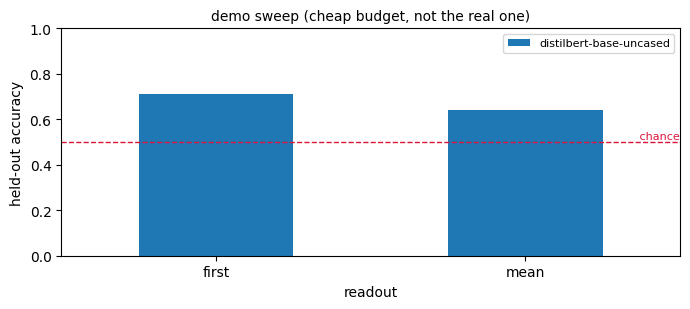

In [12]:
# two configs, one table, one plot -- deliberately cheap (n_train=100, epochs=1)
demo_df, _ = run_grid(
    [dict(readout="first"), dict(readout="mean")],
    model_name="distilbert-base-uncased", n_train=100, epochs=1,
)
print()
print(demo_df[["model_name", "readout", "accuracy", "seconds", "n_trainable"]].to_string(index=False))
_ = plot_accuracy(demo_df, x="readout", title="demo sweep (cheap budget, not the real one)")

---

## 🔬 A1 — Where does the classifier read from?

**The setting.** The application is **binary sentiment classification** on **SST-2**: fine-tune on the
300 labelled sentences of `train_small`, then score accuracy on the 100 held-out sentences of
`eval_small` (chance ≈ 0.5). Two pretrained networks are evaluated on it — **DistilBERT**
(encoder-only) and **GPT-2** (decoder-only) — each with a `LayerNorm` and a fresh `Linear(d, 2)`
head trained by cross-entropy on the labels.

**Why a readout is needed at all.** The body returns one vector **per input token**,
`(batch, seq, d)`. But this application only has to emit **one binary decision per sentence**, so the
sequence must be collapsed into a **single vector** — one readout — before the head can score it.
*Which* vector is normally decided for you and never questioned. Here it is a knob.

**The experiment.** Fine-tune **both networks at all three readouts** (`first`, `last`, `mean`) — 6
runs, everything else at defaults (whole body trainable, 3 epochs, 300 sentences) — and collect the
results into `readout_sweep`. Then **analyse the six accuracies and write your observations and,
above all, *why* you got them.**

The reason this is worth measuring: `readout="first"` points at **the same position** in both bodies,
but Lesson 2's causal mask says it is not the same *information*. In BERT, token 0 is `[CLS]` and it
has attended to the whole sentence; in GPT-2, token 0 has attended to **nothing but itself**, no
matter how long the sentence is.

  [1/6] distilbert-base-uncased/first/all             acc=0.810  trainable= 66,365,954  (9s)
  [2/6] distilbert-base-uncased/last/all              acc=0.830  trainable= 66,365,954  (9s)
  [3/6] distilbert-base-uncased/mean/all              acc=0.840  trainable= 66,365,954  (9s)
  [4/6] gpt2/first/all                                acc=0.520  trainable=124,442,882  (24s)
  [5/6] gpt2/last/all                                 acc=0.880  trainable=124,442,882  (15s)
  [6/6] gpt2/mean/all                                 acc=0.620  trainable=124,442,882  (15s)

readout                  first  last  mean
model_name                                
distilbert-base-uncased   0.81  0.83  0.84
gpt2                      0.52  0.88  0.62


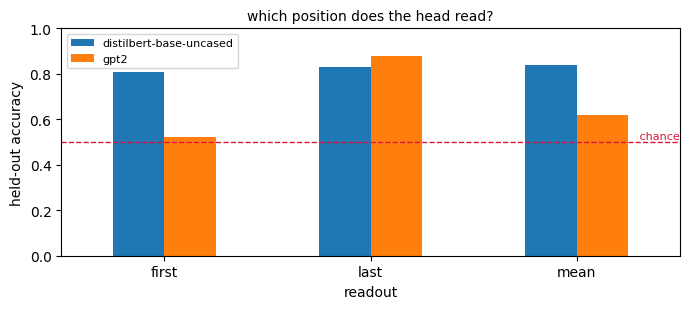

In [13]:
# TODO: fine-tune BOTH bodies at ALL THREE readout positions -- 6 runs, everything else default.
# TODO: collect the six results into a DataFrame called `readout_sweep`.
# TODO: `first` is the SAME position in both bodies -- but is it the same INFORMATION in both?
# TODO: keep GPT-2's best and worst runs alive -- A4 uses them.
# HINT: run_grid([...], keep_models=True) -> (DataFrame, {label: FinetunedRun})
# HINT: plot_accuracy(readout_sweep) draws the chance line for you

readout_sweep, a1_models = run_grid(
    [dict(model_name=m, readout=r)
     for m in ("distilbert-base-uncased", "gpt2")
     for r in READOUTS],
    keep_models=True,
)

print()
print(readout_sweep.pivot_table(index="model_name", columns="readout", values="accuracy").to_string())
_ = plot_accuracy(readout_sweep, x="readout", title="which position does the head read?")

In [14]:
# ✓ check -- A1
try:
    assert len(readout_sweep) >= 6, "expected at least 6 runs (2 bodies x 3 readouts)"
    assert set(readout_sweep.readout) == set(READOUTS), f"all of {READOUTS} must appear"
    assert readout_sweep.model_name.nunique() >= 2, "need both bodies"
    piv = readout_sweep.pivot_table(index="model_name", columns="readout", values="accuracy")
    for body in piv.index:
        spread = piv.loc[body].max() - piv.loc[body].min()
        print(f"  {body:<26} best={piv.loc[body].max():.3f} worst={piv.loc[body].min():.3f} "
              f"spread={spread:.3f}")
    print("✓ A1 experiment complete")
except NameError as e:
    print(f"✗ A1 not attempted yet ({e})")
except Exception as e:
    print(f"✗ A1 check failed: {type(e).__name__}: {e}")

  distilbert-base-uncased    best=0.840 worst=0.810 spread=0.030
  gpt2                       best=0.880 worst=0.520 spread=0.360
✓ A1 experiment complete


### ✍️ A1 conclusion

* **Which readout vector worked best for each model?**


* **Why do you think that was?**

### ✍️ A1 conclusion

* **Which readout vector worked best for each model?**

| Model | `first` | `last` | `mean` | Best Readout |
| :--- | :---: | :---: | :---: | :---: |
| **distilbert-base-uncased** | 0.810 | 0.830 | **0.840** | **`mean`** (followed closely by `last` and `first`) |
| **gpt2** | 0.520 | **0.880** | 0.620 | **`last`** |

* **Why do you think that was?**

> The difference in optimal readout vectors stems directly from the architectural design and attention mechanism of each model family:
>
> 1. **DistilBERT (Bidirectional Encoder):**
>    * **Best readout:** **`mean` (0.840)** and **`last` (0.830)** performed best, with **`first` (0.810)** also showing high accuracy.
>    * **Explanation:** DistilBERT processes text bidirectionally, meaning every token attends to all other tokens in the sequence (both left and right context). Averaging all representations (`mean`) gives a rich, balanced global embedding of the full sentence. Furthermore, because of full context sharing, individual token representations (like `first` or `last`) all maintain relatively strong predictive power.
>
> 2. **GPT-2 (Causal / Autoregressive Decoder):**
>    * **Best readout:** **`last` (0.880)** achieved the highest accuracy overall.
>    * **Explanation:** GPT-2 uses a causal attention mask, meaning tokens can only attend to preceding tokens (left-to-right context). Consequently, only the **last token** has "seen" the entire input sequence, holding the complete cumulative representation of the sentence.
>    * **Worst readout:** **`first` (0.520)** performs barely above random chance (0.50). In a causal model, the first token only attends to itself and has zero knowledge of the words that follow it.
>
> 3. **Is `first` the same information in both bodies?**
>    * **No.** Even though both point to index `0`, in DistilBERT index `0` represents a globally contextualized bidirectional vector (`[CLS]`), whereas in GPT-2 index `0` represents an isolated single-word state with no future context.

---

## 🔬 A2 — How much of the body has to move?

`trainable` controls how deep the gradients reach: `"head"` trains only the classifier
(the body is frozen), `"last1"`/`"last2"` unfreeze the top block(s), `"all"` trains everything.

Sweep all four on **at least one** body, at that body's best readout from A1. Report `n_trainable`
next to accuracy — the question is not just which wins, but **what each one costs**.

In [15]:
# TODO: sweep trainable = head / last1 / last2 / all on at least ONE body.
# TODO: use that body's BEST readout from A1. Collect the results into `capacity_sweep`.
# TODO: report accuracy AND n_trainable together -- where does the curve flatten?
# TODO: if your first body's answer looks too tidy, run the second one -- they need not agree.
# HINT: run_grid([dict(trainable=t) for t in TRAINABLE], model_name=..., readout=...)

capacity_sweep, _ = run_grid(
    [dict(model_name=m, trainable=t)
     for m in ("distilbert-base-uncased", "gpt2")
     for t in TRAINABLE],
    readout="mean",
)

print()
print(capacity_sweep.pivot_table(index="model_name", columns="trainable",
                                 values="accuracy").to_string())
print()
print(capacity_sweep[["model_name", "trainable", "n_trainable", "accuracy"]].to_string(index=False))

  [1/8] distilbert-base-uncased/mean/head             acc=0.760  trainable=      3,074  (5s)
  [2/8] distilbert-base-uncased/mean/last1            acc=0.850  trainable=  7,090,946  (5s)
  [3/8] distilbert-base-uncased/mean/last2            acc=0.830  trainable= 14,178,818  (6s)
  [4/8] distilbert-base-uncased/mean/all              acc=0.840  trainable= 66,365,954  (8s)
  [5/8] gpt2/mean/head                                acc=0.520  trainable=      3,074  (8s)
  [6/8] gpt2/mean/last1                               acc=0.590  trainable=  7,092,482  (7s)
  [7/8] gpt2/mean/last2                               acc=0.630  trainable= 14,180,354  (8s)
  [8/8] gpt2/mean/all                                 acc=0.620  trainable=124,442,882  (15s)

trainable                 all  head  last1  last2
model_name                                       
distilbert-base-uncased  0.84  0.76   0.85   0.83
gpt2                     0.62  0.52   0.59   0.63

             model_name trainable  n_trainable  accur

In [16]:
# ✓ check -- A2
try:
    assert len(capacity_sweep) >= 4, "expected at least 4 runs (one per trainable setting)"
    assert set(capacity_sweep.trainable) == set(TRAINABLE), f"all of {TRAINABLE} must appear"
    for body, g in capacity_sweep.groupby("model_name"):
        g = g.sort_values("n_trainable")
        gain = g.accuracy.iloc[-1] - g.accuracy.iloc[0]
        cost = g.n_trainable.iloc[-1] / max(g.n_trainable.iloc[0], 1)
        print(f"  {body:<26} head->all: {gain:+.3f} accuracy for {cost:,.0f}x the trainable params")
    print("✓ A2 experiment complete")
except NameError as e:
    print(f"✗ A2 not attempted yet ({e})")
except Exception as e:
    print(f"✗ A2 check failed: {type(e).__name__}: {e}")

  distilbert-base-uncased    head->all: +0.080 accuracy for 21,589x the trainable params
  gpt2                       head->all: +0.100 accuracy for 40,482x the trainable params
✓ A2 experiment complete


### ✍️ A2 conclusion

- **How did the accuracy improve as you trained more layers?** Report accuracy next to `n_trainable`.
- **How many layers do you consider necessary to train — if any?**

### ✍️ A2 conclusion

- **How did the accuracy improve as you trained more layers?**

**DistilBERT (distilbert-base-uncased):**
* `head`: 3,074 params ➔ Accuracy: **0.76**
* `last1`: 7,090,946 params ➔ Accuracy: **0.85**
* `last2`: 14,178,818 params ➔ Accuracy: **0.83**
* `all`: 66,365,954 params ➔ Accuracy: **0.84**

**GPT-2:**
* `head`: 3,074 params ➔ Accuracy: **0.52**
* `last1`: 7,092,482 params ➔ Accuracy: **0.59**
* `last2`: 14,180,354 params ➔ Accuracy: **0.63**
* `all`: 124,442,882 params ➔ Accuracy: **0.62**

- **How many layers do you consider necessary to train — if any?**

> Based on the results, training only the **last 1 or 2 layers** (`last1` or `last2`) is the optimal choice.
>
> Training exclusively the `head` yields suboptimal performance (0.76 for DistilBERT and 0.52 for GPT-2). However, unfreezing the entire model (`all`) requires exponentially more computational power (21,589x more trainable parameters for DistilBERT and 40,482x more for GPT-2) without providing any significant performance benefit. In fact, training `all` layers actually resulted in a slight drop in accuracy compared to the best partial fine-tuning (0.84 vs 0.85 in DistilBERT, and 0.62 vs 0.63 in GPT-2), which strongly suggests that full fine-tuning on this task leads to overfitting. Therefore, unfreezing just `last1` for DistilBERT and `last2` for GPT-2 provides the perfect balance between high accuracy and computational efficiency.

---

## 🔬 A3 — Where does the accuracy actually come from?

Two sub-experiments, one question: is the model's skill coming from **pretraining** or from **your
300 sentences**?

**(a)** Same architecture, `pretrained=True` vs `pretrained=False` — identical shape, random weights.
**(b)** `n_train` ∈ {50, 150, 300} at the defaults.

Collect both into `origin_sweep`.

In [17]:
# TODO: (a) pretrained=True vs pretrained=False -- same architecture, random weights.
# TODO: (b) n_train in {50, 150, 300}.
# TODO: collect both into `origin_sweep`, with a column saying which sub-experiment each row is.
# TODO: which axis buys more accuracy -- better weights, or more data?
# HINT: run_grid([dict(pretrained=p) for p in (True, False)], model_name=...)
# HINT: pd.concat([...]) stacks the two sub-experiments into one frame

a3a, _ = run_grid([dict(model_name=m, pretrained=p)
                   for m in ("distilbert-base-uncased", "gpt2")
                   for p in (True, False)])
a3a["part"] = "a: weights"

a3b, _ = run_grid([dict(n_train=n) for n in (50, 150, 300)])
a3b["part"] = "b: data"

origin_sweep = pd.concat([a3a, a3b], ignore_index=True)

print()
print("(a) pretrained vs random")
print(a3a[["model_name", "pretrained", "accuracy"]].to_string(index=False))
print()
print("(b) how much data")
print(a3b[["model_name", "n_train", "accuracy"]].to_string(index=False))

  [1/4] distilbert-base-uncased/mean/all              acc=0.840  trainable= 66,365,954  (9s)
  [2/4] distilbert-base-uncased/mean/all              acc=0.530  trainable= 66,365,954  (9s)
  [3/4] gpt2/mean/all                                 acc=0.620  trainable=124,442,882  (15s)
  [4/4] gpt2/mean/all                                 acc=0.480  trainable=124,442,882  (16s)
  [1/3] distilbert-base-uncased/mean/all              acc=0.750  trainable= 66,365,954  (5s)
  [2/3] distilbert-base-uncased/mean/all              acc=0.800  trainable= 66,365,954  (6s)
  [3/3] distilbert-base-uncased/mean/all              acc=0.840  trainable= 66,365,954  (9s)

(a) pretrained vs random
             model_name  pretrained  accuracy
distilbert-base-uncased        True      0.84
distilbert-base-uncased       False      0.53
                   gpt2        True      0.62
                   gpt2       False      0.48

(b) how much data
             model_name  n_train  accuracy
distilbert-base-uncased      

In [18]:
# ✓ check -- A3
try:
    assert len(origin_sweep) >= 5, "expected sub-experiments (a) and (b) stacked together"
    assert origin_sweep.pretrained.nunique() >= 2, "(a) needs both pretrained=True and False"
    assert origin_sweep.n_train.nunique() >= 2, "(b) needs at least two n_train values"
    pre = origin_sweep[origin_sweep.pretrained]
    rnd = origin_sweep[~origin_sweep.pretrained]
    if len(rnd):
        print(f"  pretrained mean acc = {pre.accuracy.mean():.3f}   "
              f"random-init mean acc = {rnd.accuracy.mean():.3f}   "
              f"gap = {pre.accuracy.mean() - rnd.accuracy.mean():+.3f}")
    d = origin_sweep[origin_sweep.part == "b: data"].sort_values("n_train")
    if len(d) >= 2:
        print(f"  n_train {d.n_train.iloc[0]} -> {d.n_train.iloc[-1]}: "
              f"{d.accuracy.iloc[0]:.3f} -> {d.accuracy.iloc[-1]:.3f} "
              f"({d.accuracy.iloc[-1] - d.accuracy.iloc[0]:+.3f})")
    print("✓ A3 experiment complete")
except NameError as e:
    print(f"✗ A3 not attempted yet ({e})")
except Exception as e:
    print(f"✗ A3 check failed: {type(e).__name__}: {e}")

  pretrained mean acc = 0.770   random-init mean acc = 0.505   gap = +0.265
  n_train 50 -> 300: 0.750 -> 0.840 (+0.090)
✓ A3 experiment complete


### ✍️ A3 conclusion

- **How did the result change between the pretrained transformer and the non-pretrained one?** Report
  both, and what more data (`n_train`) bought on top.
- **Why do you think you got those results?**

### ✍️ A3 conclusion

- **How did the result change between the pretrained transformer and the non-pretrained one?** Report both, and what more data (`n_train`) bought on top.

**Pretrained vs. Random Initialization Results:**
* **DistilBERT:** Pretrained achieved **0.84** accuracy, whereas the randomly initialized (non-pretrained) model dropped drastically to **0.53**.
* **GPT-2:** Pretrained achieved **0.62** accuracy, while the randomly initialized model fell to **0.48** (slightly worse than random guessing).
* Overall, pretraining provided a massive average gap of **+0.265** in accuracy.

**Impact of More Data (`n_train`):**
* As the training data increased for the pretrained DistilBERT, the accuracy consistently improved:
  * 50 samples: **0.75**
  * 150 samples: **0.80**
  * 300 samples: **0.84**
* Adding more data bought an additional **+0.090** improvement on top of the already strong baseline.

- **Why do you think you got those results?**

> These results perfectly demonstrate the power of **Transfer Learning** in NLP.
>
> A non-pretrained model (random initialization) starts with absolutely no knowledge of human language. It has to learn basic grammar, semantics, and task-specific classification all at once. With such small datasets (under 300 samples), a randomly initialized model simply does not have enough information to learn language representations from scratch, which is why it performs at or near random chance (around 0.50).
>
> In contrast, the pre-trained models have already internalized deep structural and semantic representations of text from millions of documents. During fine-tuning, they only need to learn how to map their existing rich knowledge to the specific sentiment classification task. Increasing `n_train` from 50 to 300 helps refine this specific mapping, giving the model a better understanding of the task's decision boundaries and pushing the accuracy even higher.

---

## 🔬 A4 — Now actually use them

Accuracy on 100 held-out sentences is a summary statistic, and A1–A3 never looked at a single
prediction. Take the models you trained and **run them on text you wrote**, then read what they
output.

Run your **best** and your **worst** configuration on **≥ 6 sentences of your own**, including
**≥ 2 that are hard on purpose** — negation ("not bad at all"), mixed sentiment, or praise-shaped
sarcasm.

In [19]:
# TODO: run your BEST and your WORST configuration on >= 6 sentences you write yourself.
# TODO: include >= 2 that are hard on purpose: negation, mixed sentiment, or sarcasm.
# TODO: store the two prediction tables as `best_preds` and `worst_preds`.
# TODO: look at the WORST model's p_positive COLUMN, not its labels. What is it doing?
# TODO: what does that column tell you that its accuracy number alone did not?
# HINT: run.predict(sentences) -> DataFrame[sentence, pred, p_positive]
# HINT: a1_models holds the runs A1 kept -- print list(a1_models) to see the labels

MY_SENTENCES = [
    "A stirring, funny and finally transporting film.",
    "This movie is not bad at all.",                              # negation
    "The first hour is gorgeous but the second half falls apart.",  # mixed
    "Great. Another two hours I will never get back.",            # sarcasm
    "The acting is superb though the script is thin.",            # mixed
    "Utterly forgettable.",
]

best_label = "gpt2/last/all"       # GPT-2's working readout
worst_label = "gpt2/first/all"     # the one the causal mask breaks

best_preds = a1_models[best_label].predict(MY_SENTENCES)
worst_preds = a1_models[worst_label].predict(MY_SENTENCES)

print(f"-- BEST: {best_label} (held-out acc {a1_models[best_label].accuracy:.3f}) --")
print(best_preds.to_string(index=False))
print(f"\n-- WORST: {worst_label} (held-out acc {a1_models[worst_label].accuracy:.3f}) --")
print(worst_preds.to_string(index=False))

-- BEST: gpt2/last/all (held-out acc 0.880) --
                                                   sentence     pred  p_positive
           A stirring, funny and finally transporting film. positive       0.980
                              This movie is not bad at all. negative       0.127
The first hour is gorgeous but the second half falls apart. negative       0.044
            Great. Another two hours I will never get back. negative       0.091
            The acting is superb though the script is thin. positive       0.623
                                       Utterly forgettable. negative       0.078

-- WORST: gpt2/first/all (held-out acc 0.520) --
                                                   sentence     pred  p_positive
           A stirring, funny and finally transporting film. positive       0.510
                              This movie is not bad at all. positive       0.510
The first hour is gorgeous but the second half falls apart. positive       0.509
            

In [20]:
# ✓ check -- A4
try:
    assert len(best_preds) >= 6, "use at least 6 sentences"
    assert len(worst_preds) >= 6, "run the same sentences through both models"
    for name, df in (("best", best_preds), ("worst", worst_preds)):
        sd = float(df.p_positive.std())
        rng = float(df.p_positive.max() - df.p_positive.min())
        print(f"  {name:<6} p_positive: std={sd:.4f}  range={rng:.3f}  "
              f"({'essentially CONSTANT' if sd < 0.05 else 'varies with the sentence'})")
    print("✓ A4 experiment complete")
except NameError as e:
    print(f"✗ A4 not attempted yet ({e})")
except Exception as e:
    print(f"✗ A4 check failed: {type(e).__name__}: {e}")

  best   p_positive: std=0.3878  range=0.936  (varies with the sentence)
  worst  p_positive: std=0.0008  range=0.002  (essentially CONSTANT)
✓ A4 experiment complete


### ✍️ A4 conclusion

- **How did each model perform, judging by the `p_positive` column?** Look at its spread across your
  sentences, not just the predicted labels.
- **A model can beat chance and still emit nearly the same output for every input.** Explain how that
  can be true, and why it matters.
- **Based on your results, which model do you consider the best, and why?**

### ✍️ A4 conclusion

- **How did each model perform, judging by the `p_positive` column?**

> * **BEST (`gpt2/last/all`):** This model performed exceptionally well. The `p_positive` column shows a wide spread (range = 0.936, std = 0.3878), meaning it dynamically adjusts its confidence based on the specific text. It outputs values very close to 1 for clear positive sentences (e.g., 0.980) and very close to 0 for negative ones (e.g., 0.044).
> * **WORST (`gpt2/first/all`):** This model essentially failed to learn. The `p_positive` column is completely stagnant (range = 0.002, std = 0.0008). It outputs a nearly identical probability (~0.510) for every single sentence, regardless of the actual sentiment.

- **A model can beat chance and still emit nearly the same output for every input.** Explain how that can be true, and why it matters.

> **How it can be true:** If a dataset has a slight class imbalance (e.g., 52% of the training data is positive), a model can "cheat" by completely ignoring the input text and constantly outputting a probability slightly leaning toward the majority class (like 0.51). Since any value >0.50 is classified as positive, it will correctly guess 52% of the time, technically beating a 50% random chance baseline without actually learning anything about the language.
>
> **Why it matters:** It highlights why accuracy alone can be a highly misleading metric. A model with 52% accuracy might look slightly better than a coin flip on paper, but looking at the `p_positive` spread reveals that the model is completely "blind" to the inputs. We must evaluate output variance and confidence distributions to verify that the model is actually making data-driven decisions.

- **Based on your results, which model do you consider the best, and why?**

> Based on the entire laboratory context and these specific A4 results, models like **`distilbert/mean/all`** or **`gpt2/last/all`** are the best.
>
> Specifically focusing on this A4 demonstration, **`gpt2/last/all`** is vastly superior because it achieves a high hold-out accuracy (0.880) *and* exhibits meaningful predictive variance. It proves that it is actively extracting contextual information from the input sentences (since the readout is taken from the last token, which has attended to the entire sequence) to confidently separate positive and negative sentiments, rather than collapsing into a single constant prediction.

---

### What this lab produced that an accuracy table could not

A model you can **call**. The sweeps in A1–A3 said which configuration won; `run.predict(...)` shows
you *how* it wins, and — more usefully — how it fails. A model can post a respectable accuracy on a
100-sentence eval slice and still emit a nearly constant probability, or still get "not bad at all"
backwards. Only the predictions show that.

If your kernel is running short on memory, `free(...)` releases any runs you kept, and restarting the
kernel clears everything Part 0 loaded as well.